# **Data Loaders and Augmentation (MONAI)**

> **Author:** Sahika Betul Yayli, MD  

In this notebook, we focus on one of the most powerful (and often misunderstood) components of deep learning in medical imaging: **data augmentation**.

Medical imaging datasets are rarely perfect. They are usually limited in size, highly heterogeneous, and influenced by scanner differences, acquisition protocols, and patient-specific variability. Because of this, models can easily overfit to the exact appearance of the training data.

Augmentation provides a practical solution: it helps models learn features that remain stable across realistic variations.

---

## What augmentation really does

At its core, augmentation applies controlled transformations to training images so that the model learns:

> “This is still the same anatomy and diagnosis, even if the image looks slightly different.”

By exposing the network to plausible variations, augmentation improves robustness to real-world factors such as:

- patient positioning differences  
- mild motion artifacts or noise  
- intensity and contrast shifts across scanners  
- acquisition variability between institutions  

---

## What augmentation does **not** do

Augmentation is not magic. It cannot solve every limitation of medical datasets:

- It does **not** generate truly new rare pathology  
- It cannot fix incorrect or noisy ground truth labels  
- Excessive or unrealistic transformations may harm performance  

**Key principle:** augmentations must remain **clinically plausible**.

---

### What you will learn 
- What augmentation really is: applying controlled mathematical transformations (e.g., rotations, intensity shifts, noise) to create realistic variations of the same anatomy 
- Why augmentation improves generalization: how it encourages models to learn robust clinical features instead of memorizing pixel-level patterns 
- The intuition behind common augmentations:
  - geometric transforms (rotation, scaling, flipping)
  - intensity transforms (brightness/contrast changes)
  - noise-based transforms (Gaussian noise, blur)
- When augmentation becomes harmful: how unrealistic transformations can destroy anatomical plausibility and reduce performance 
- How to visualize augmentation effects using subplot grids, which is essential for safe medical AI development 
- Supporting concepts (briefly):
 - how data is loaded efficiently with Dataset and DataLoader 
 - why augmentation must be applied only to the training set 
 - how samplers help when classes are imbalanced

---

## **Dataset used**

To keep everything lightweight and fully runnable, we use the **ChestMNIST** dataset from the **MedMNIST** collection.

ChestMNIST is a simple but realistic medical imaging benchmark based on chest X-rays, making it ideal for inspecting augmentation effects and understanding how models learn robustness from limited clinical data.

## 1. Setup

In [1]:
import cv2
import random
import numpy as np
import torch
import matplotlib.pyplot as plt

from torchvision import transforms
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
from medmnist import ChestMNIST

# Where ChestMNIST will be stored (downloaded once, reused everywhere)
DATA_ROOT = "./data"


## 2. Reproducibility (important for debugging augmentations)

When we apply augmentation, we introduce randomness into training:
- one image may be rotated by 5° in one epoch
- and by 15° in the next
- noise intensity may change every time it is loaded
This randomness is helpful for generalization, but it also makes debugging difficult.

**Why reproducibility matters**
Setting random seeds ensures that:
- you can see the same augmented examples again
- experiments can be fairly compared
- unexpected performance changes are not caused by random augmentation differences
- results can be trusted and reported in academic work

In medical AI, reproducibility is especially important because we want models to be:
- scientifically reliable
- clinically interpretable
- safe to validate across cohorts

So before experimenting with augmentations, we first fix the random seeds.

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


## 3. Load ChestMNIST

Before applying augmentations, we need a dataset that is:
- small and easy to download
- quick to run on any machine
- still representative of real medical imaging workflows

For this notebook, we use ChestMNIST (MedMNIST), a lightweight example dataset provided by MONAI.
It contains simple 2D medical image categories (e.g., chest X-rays, hand images), making it ideal for learning and visualizing augmentation effects.

The goal here is not high performance — it is to have a clean sandbox where we can clearly see what each augmentation does.


In [3]:
dataset_raw = ChestMNIST(
    split="train",
    download=True,
    root=DATA_ROOT,
    transform=None  # keep raw for splitting / visualization
)
print("Number of training images:", len(dataset_raw))


Number of training images: 78468


## 4. Transforms: what we must do vs what we choose to randomize

During training, images are not loaded all at once. Instead, they are fed to the model step by step:
- Dataset defines what one sample is (image + label) and is usually where augmentations are applied.
- DataLoader controls how samples are grouped into batches, shuffled, and loaded efficiently.

Key idea: augmentation happens during data loading, so the model sees slightly different versions of the same image each epoch.

In medical imaging, we apply transforms for two very different reasons:

**1. Preprocessing (required)**

These are steps that make the data usable and consistent.

For example:

- loading the image correctly  
- ensuring a standard shape or orientation  
- normalizing intensity values  

Preprocessing is applied to **every split** (train, validation, and test), because it defines what the model input looks like.


**2. Augmentation (training-only)**

Augmentation is different: it introduces *controlled randomness*.

The goal is to expose the model to realistic variations, such as:

- slight rotations  
- scanner noise  
- brightness or contrast differences  

Augmentations are applied **only during training**, so the model learns robust features instead of memorizing the dataset.


**Key safety rule**

Validation and test data should reflect the real clinical world.

So we never apply random augmentation at evaluation time — otherwise we are testing the transform, not the model.

In [4]:
preprocess = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),  # -> torch.Tensor (C,H,W) in [0,1]
])

val_xform = preprocess

# A reasonable *training* augmentation pipeline for chest X-rays (mild, clinically plausible).
train_aug = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomAffine(
        degrees=10,
        translate=(0.06, 0.06),
        scale=(0.9, 1.1),
    ),
    transforms.RandomHorizontalFlip(p=0.5),  # optional; remove if laterality matters
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
])


## 5. Train/validation split

For real clinical projects, split at the **patient / study level** to avoid leakage.  

A validation set is supposed to answer a simple question:

**“Will this model work on new patients?”**

That only holds if validation data is truly *independent* from training data.

**Why leakage happens in medical imaging**

Medical datasets often contain multiple samples from the same patient (e.g., many slices, frames, or timepoints).  
If samples from one patient end up in both **train** and **validation**, the model can indirectly “recognize” that patient-specific appearance and the validation score becomes **artificially high**.

This is called **data leakage**.

**The mindset to remember**

- **Unit of prediction** in clinic = usually the **patient**  
- Therefore, the safest split is typically **patient-level** (or study-level)  
- Random splitting is only acceptable when you are confident samples are independent



### Patient-level splitting in practice (real medical projects)

In real clinical datasets, you often have a **patient ID** (or study ID) for each image:

```python
patient_ids = ["P001", "P001", "P002", "P003", ...]
```

In that case, you should split by patient, not by image.
A clean way to do this is to use group-based splitting, which guarantees that no patient appears in both sets:

In [5]:
'''
from sklearn.model_selection import GroupShuffleSplit
import numpy as np

idx = np.arange(len(dataset))

gss = GroupShuffleSplit(test_size=0.2, random_state=SEED)

train_idx, val_idx = next(gss.split(idx, groups=patient_ids))
'''

'\nfrom sklearn.model_selection import GroupShuffleSplit\nimport numpy as np\n\nidx = np.arange(len(dataset))\n\ngss = GroupShuffleSplit(test_size=0.2, random_state=SEED)\n\ntrain_idx, val_idx = next(gss.split(idx, groups=patient_ids))\n'

This produces training and validation indices with zero patient overlap.

Our example dataset does not provide patient identifiers, so we cannot apply a true patient-level split in this notebook.
Instead, we use a simple random split to demonstrate the workflow:

In [6]:
idx = np.arange(len(dataset_raw))
train_idx, val_idx = train_test_split(idx, test_size=0.2, random_state=SEED, shuffle=True)

print("train:", len(train_idx), "val:", len(val_idx))


train: 62774 val: 15694


## 6. Build training and validation datasets

We create two dataset objects:
- **Training** uses `train_aug` (stochastic)
- **Validation** uses `val_xform` (deterministic)

Then we apply our indices using `Subset`.


**Augmentation lives inside the dataset**, so every time the model asks for a sample during training, it can receive a slightly different (augmented) version of the same image.

For validation, we keep things deterministic so the evaluation reflects the real-world data distribution.

In the next cell, we build the datasets and run a quick sanity check by loading one sample and printing its shape and dtype.


In [7]:
train_ds_full = ChestMNIST(
    split="train",
    download=False,
    root=DATA_ROOT,
    transform=train_aug
)

val_ds_full = ChestMNIST(
    split="train",
    download=False,
    root=DATA_ROOT,
    transform=val_xform
)

train_ds = Subset(train_ds_full, train_idx)
val_ds   = Subset(val_ds_full, val_idx)

x0, _ = train_ds[0]
print("sample tensor shape:", tuple(x0.shape), "| dtype:", x0.dtype)


sample tensor shape: (1, 128, 128) | dtype: torch.float32


## 7. Create DataLoaders

A `DataLoader` handles batching, shuffling, and parallel loading.


In [8]:
BATCH_SIZE = 32
NUM_WORKERS = 2  # increase if your environment supports it

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

xb, yb = next(iter(train_loader))
print("batch:", xb.shape, "| labels shape:", np.array(yb).shape)


batch: torch.Size([32, 1, 128, 128]) | labels shape: (32, 14)


## 8. Visual sanity check: preview common augmentations

Always inspect augmentations before training.

Below we preview three common augmentation types on the **same image**:
1. Rotation  
2. Gaussian noise  
3. Brightness/contrast jitter (“windowing-like”)

Then we preview a **mixed** pipeline.

> For teaching purposes, the single-augmentation demos below intentionally use *strong* settings so the effect is obvious.


In [9]:
def show_augmentations(ds_no_aug, ds_aug, index: int, n_aug: int = 11, title: str = ""):
    """Show original vs multiple stochastic augmented views for the same image (label ignored)."""
    x0, _ = ds_no_aug[index]

    rows = 2
    cols = int(np.ceil((n_aug + 1) / rows))
    fig, axes = plt.subplots(rows, cols, figsize=(3.2 * cols, 3.2 * rows))
    axes = np.array(axes).reshape(rows, cols)

    axes[0, 0].imshow(x0.squeeze(), cmap="gray")
    axes[0, 0].set_title("Original")
    axes[0, 0].axis("off")

    k = 0
    for r in range(rows):
        for c in range(cols):
            if r == 0 and c == 0:
                continue
            if k >= n_aug:
                axes[r, c].axis("off")
                continue
            xa, _ = ds_aug[index]  # stochastic each call
            axes[r, c].imshow(xa.squeeze(), cmap="gray")
            axes[r, c].set_title(f"Aug {k+1}")
            axes[r, c].axis("off")
            k += 1

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


In [10]:
# Visualization datasets (no re-download)
train_ds_no_aug_vis = ChestMNIST(
    split="train",
    transform=preprocess,
    root=DATA_ROOT,
    download=False
)

rand_i = random.randint(0, len(train_ds_no_aug_vis) - 1)


### 8.1 Rotation

Simulates patient positioning differences.  
Here we use **±50°** (intentionally strong) to highlight how rotation can become unrealistic if overdone.


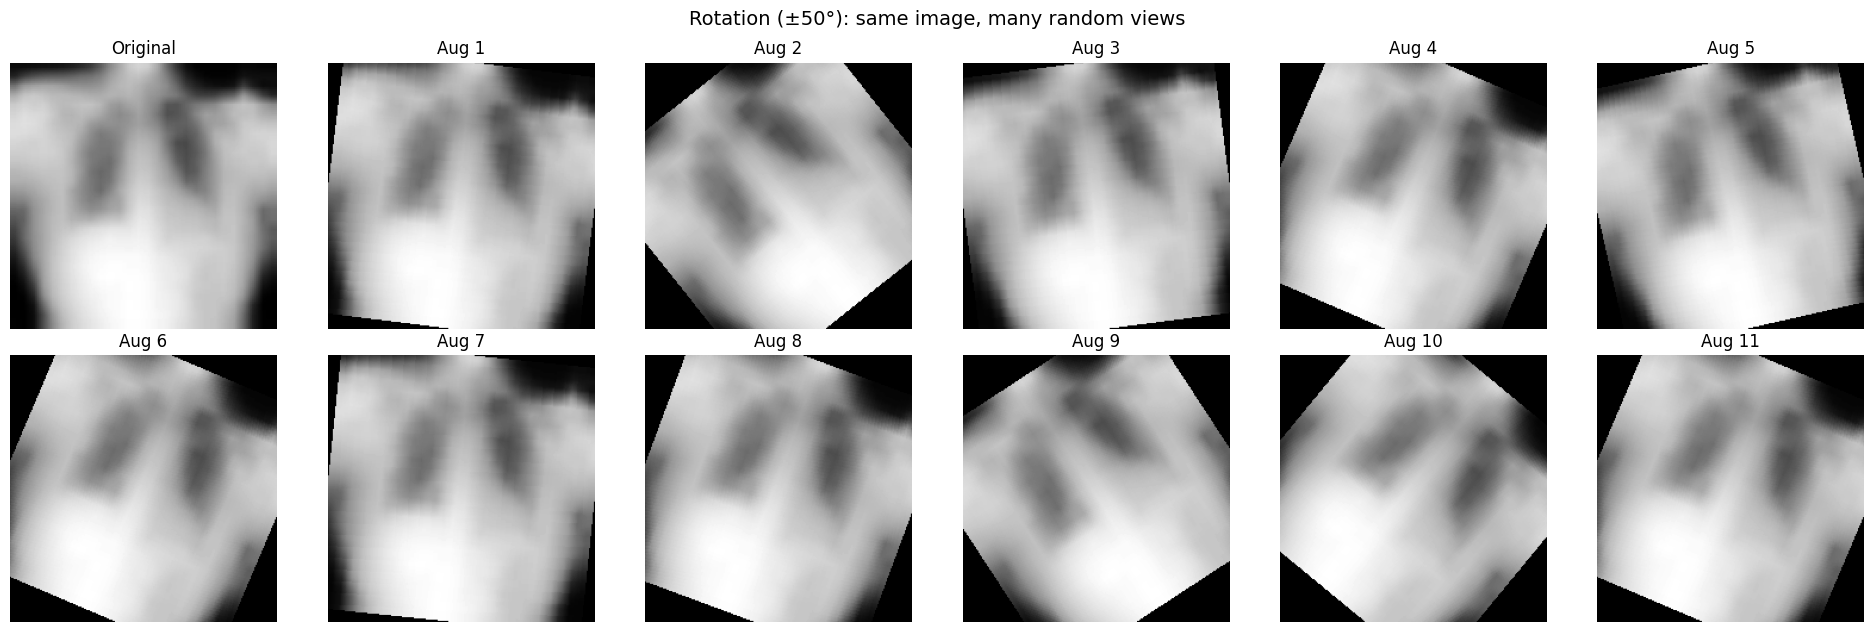

In [11]:
rotation_aug = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomRotation(degrees=50),
    transforms.ToTensor(),
])

train_ds_rot = ChestMNIST(split="train", root=DATA_ROOT, download=False, transform=rotation_aug)

show_augmentations(
    ds_no_aug=train_ds_no_aug_vis,
    ds_aug=train_ds_rot,
    index=rand_i,
    n_aug=11,
    title="Rotation (±50°): same image, many random views"
)


### 8.2 Gaussian noise

Simulates scanner / acquisition noise and graininess.  
Here we add noise with **σ=0.1** (intentionally strong for visibility).


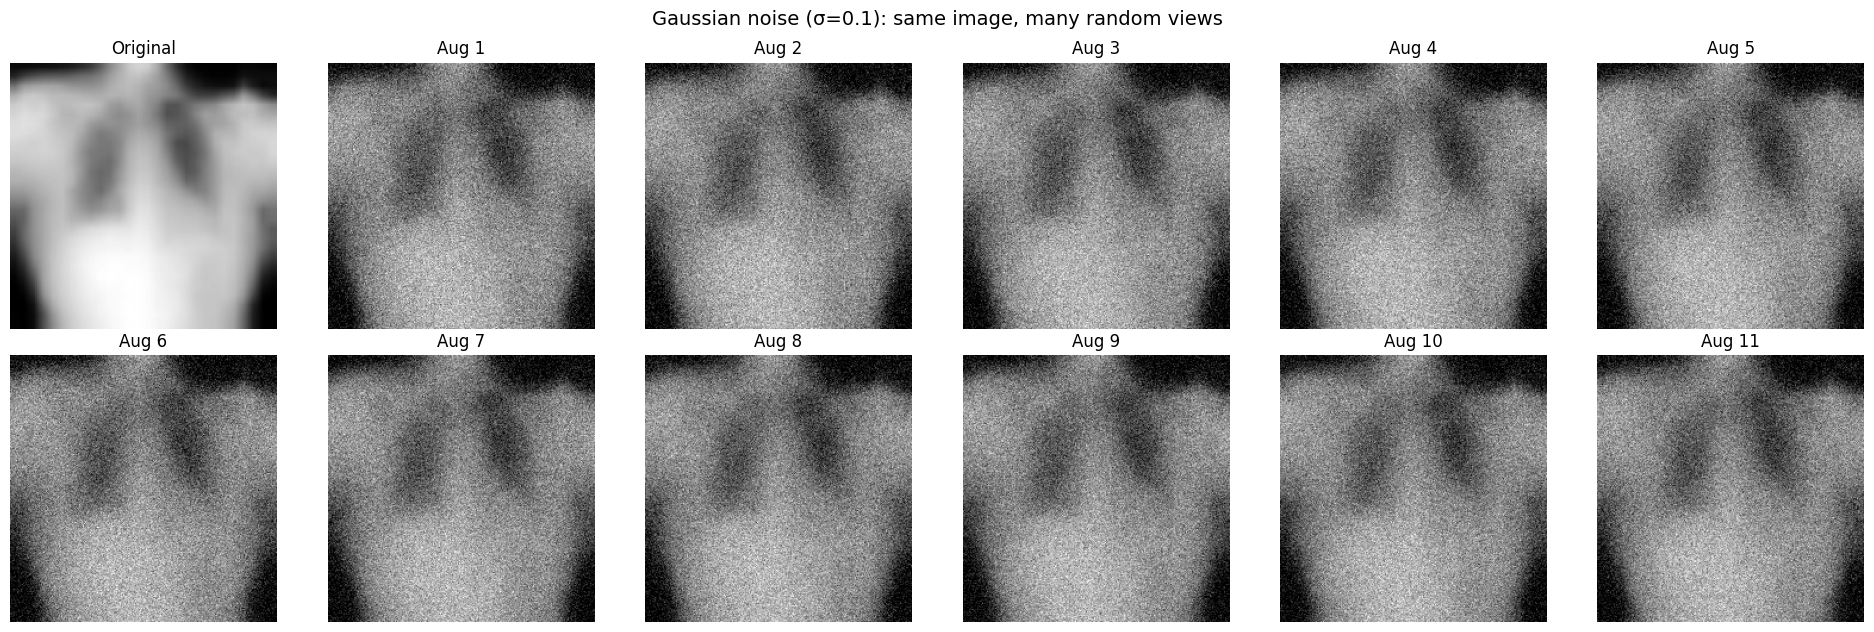

In [12]:
noise_aug = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: torch.clamp(x + 0.1 * torch.randn_like(x), 0, 1)),
])

train_ds_noise = ChestMNIST(split="train", root=DATA_ROOT, download=False, transform=noise_aug)

show_augmentations(
    ds_no_aug=train_ds_no_aug_vis,
    ds_aug=train_ds_noise,
    index=rand_i,
    n_aug=11,
    title="Gaussian noise (σ=0.1): same image, many random views"
)


### 8.3 Brightness/contrast jitter (“windowing-like”)

Mimics variation from different scanners, protocols, and preprocessing pipelines.  
Here we use a large jitter (**0.45**) to make the effect obvious.


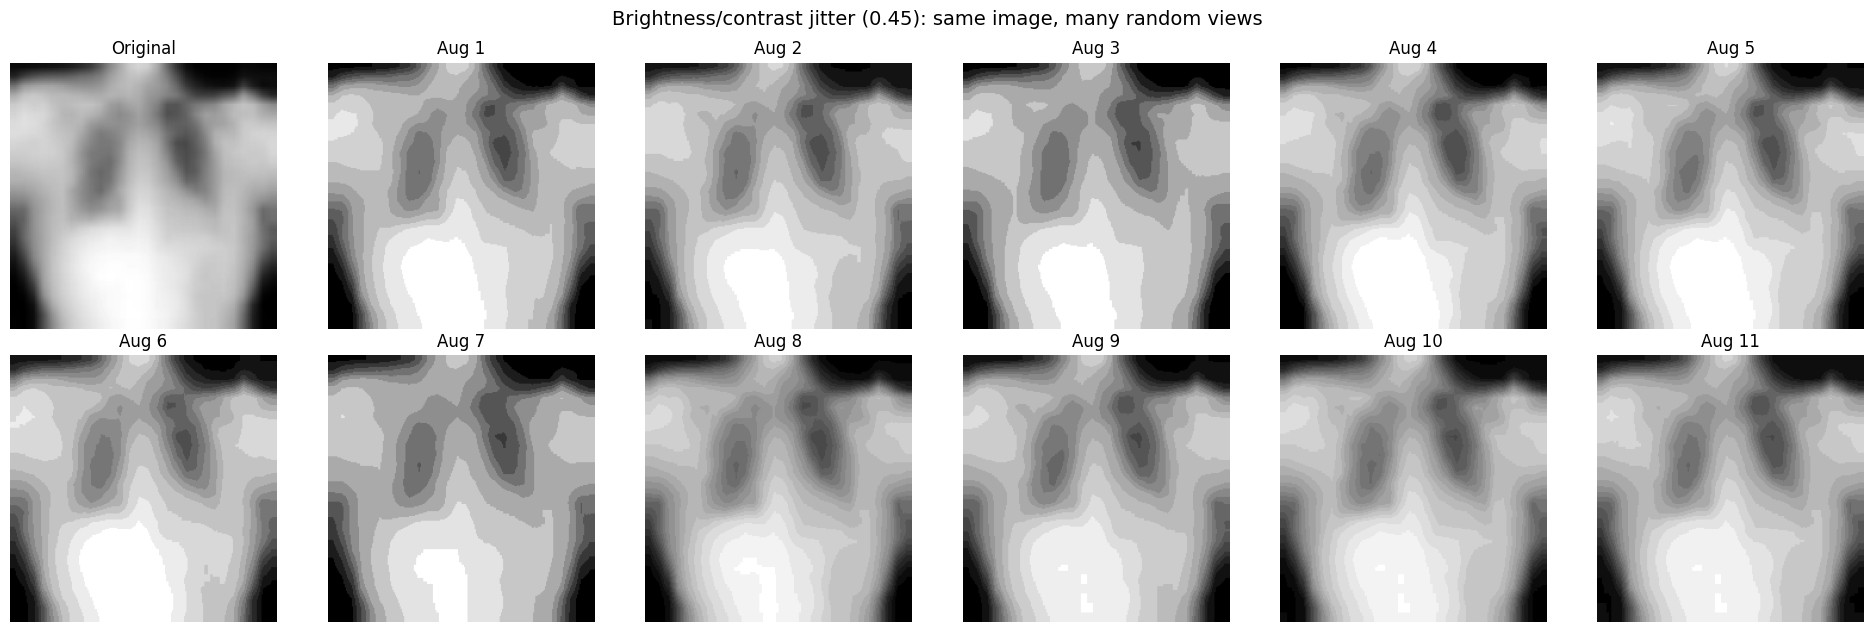

In [13]:
intensity_aug = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ColorJitter(brightness=(0.2, 0.45), contrast=(0.2, 0.45)),
    transforms.ToTensor(),
])

train_ds_intensity = ChestMNIST(split="train", root=DATA_ROOT, download=False, transform=intensity_aug)

show_augmentations(
    ds_no_aug=train_ds_no_aug_vis,
    ds_aug=train_ds_intensity,
    index=rand_i,
    n_aug=11,
    title="Brightness/contrast jitter (0.45): same image, many random views"
)


### 8.4 CLAHE (local contrast enhancement)

**CLAHE** increases contrast **locally** (tile-by-tile), which can make subtle structures more visible.
It is widely used in medical imaging (e.g., X-ray, endoscopy) when global contrast is insufficient.

In clinical imaging, many important findings are **low-contrast** and can be easily missed by both humans and models, such as:

- subtle lung opacities  
- faint interstitial patterns  
- small nodules  
- weak soft-tissue boundaries  

CLAHE is often preferred because it enhances these local intensity differences **without uniformly boosting the entire image**, making it more suitable than standard histogram equalization.

**Caution:** CLAHE can also amplify noise and create overly “crispy” textures.
Always visualize the effect and keep parameters moderate.


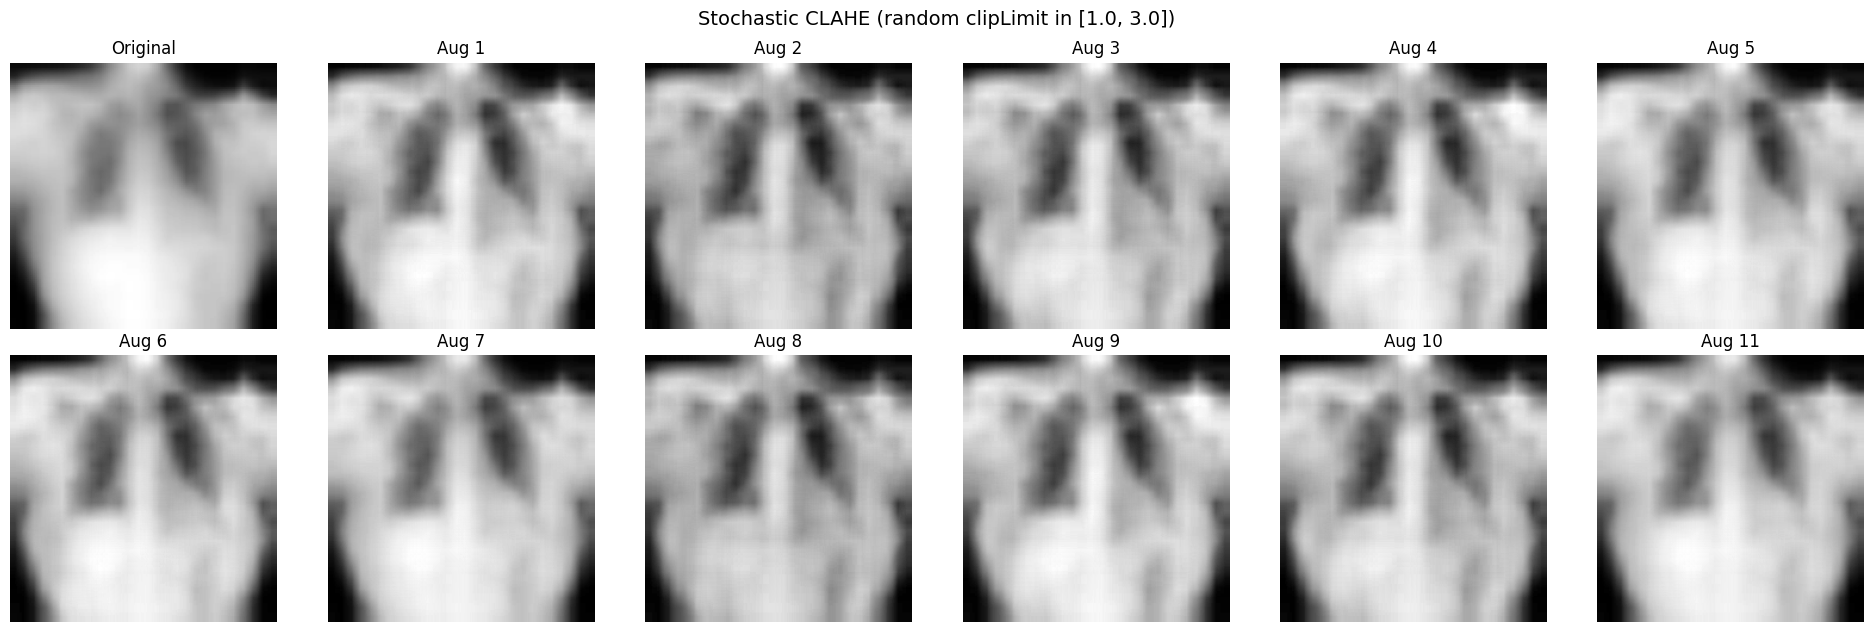

In [14]:
clahe_aug = transforms.Compose([
    transforms.Resize((224,224)),

    transforms.Lambda(
        lambda img: transforms.ToPILImage()(
            cv2.createCLAHE(
                clipLimit=float(np.random.uniform(1.0, 3.0)),  # avoid 0
                tileGridSize=(8, 8)
            ).apply(
                np.array(img.convert("L"), dtype=np.uint8)
            )
        )
    ),

    transforms.ToTensor(),
])

train_ds_clahe = ChestMNIST(
    split="train",
    root=DATA_ROOT,
    download=False,
    transform=clahe_aug
)

show_augmentations(
    ds_no_aug=train_ds_no_aug_vis,
    ds_aug=train_ds_clahe,
    index=rand_i,
    n_aug=11,
    title="Stochastic CLAHE (random clipLimit in [1.0, 3.0])"
)


### 8.5 Unsharp masking (mild sharpening)

Sharpening emphasizes edges and fine structures.

This is sometimes used in medical imaging pipelines to enhance boundaries,  
but it can also amplify noise.

Use only mild sharpening and always visually inspect the result.


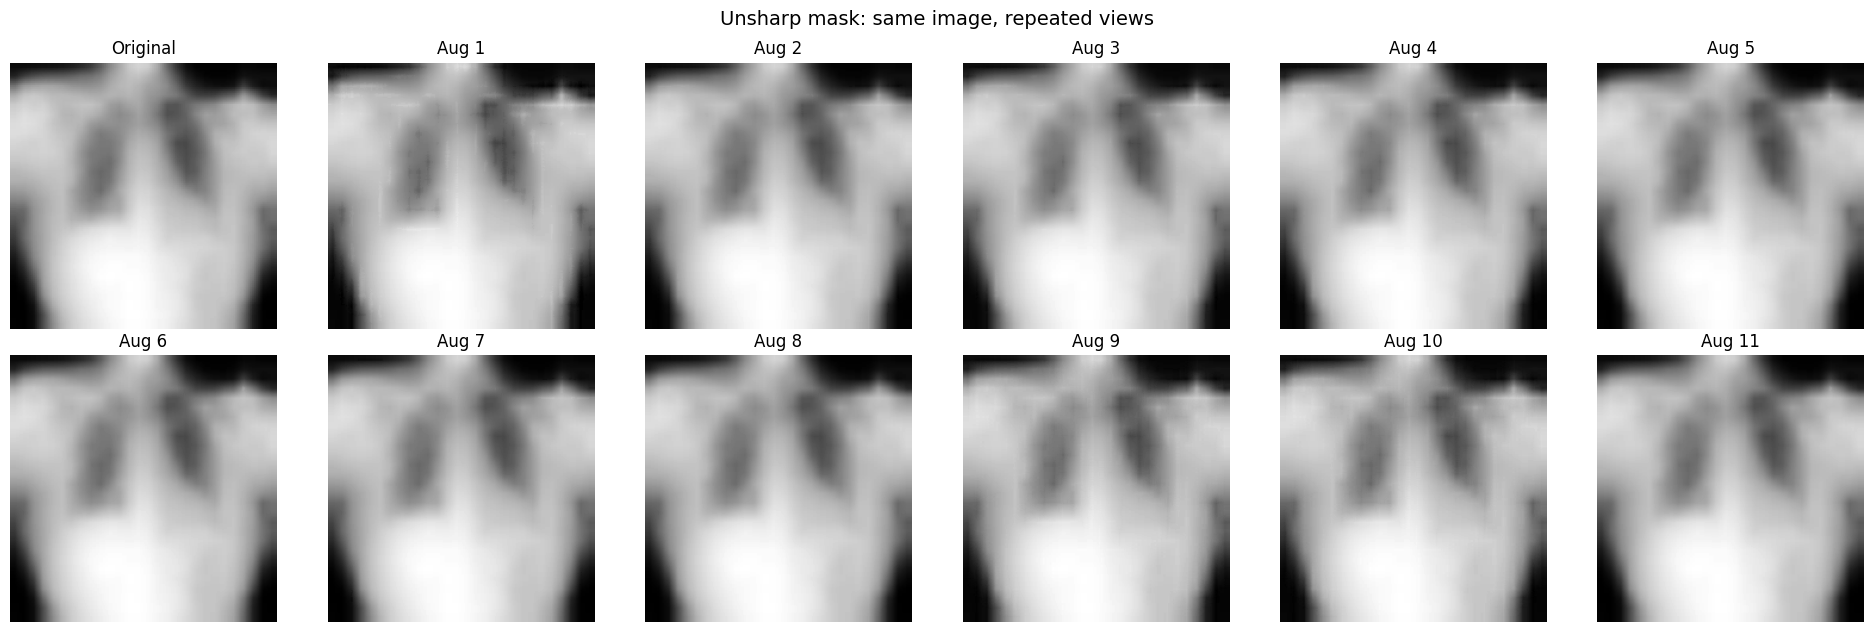

In [15]:
from PIL import ImageFilter

sharpen_aug = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.Lambda(
        lambda img: img.filter(
            ImageFilter.UnsharpMask(
                radius=float(np.random.uniform(1.0, 3.0)),
                percent=int(np.random.uniform(80, 200)),
                threshold=int(np.random.uniform(0, 6)),
            )
        )
    ),
    transforms.ToTensor(),
])


train_ds_sharp = ChestMNIST(
    split="train",
    root=DATA_ROOT,
    download=False,
    transform=sharpen_aug
)

show_augmentations(
    ds_no_aug=train_ds_no_aug_vis,
    ds_aug=train_ds_sharp,
    index=rand_i,
    n_aug=11,
    title="Unsharp mask: same image, repeated views"
)


### 8.6 Random cropping / zoom (field-of-view variability)

In clinical imaging, the region of interest (ROI) is not always perfectly centered.

Different scanners, protocols, and patient positioning can lead to:
- zoom-in / zoom-out differences  
- slightly different framing  
- partial shifts of anatomy within the image  

Random cropping helps models become robust to these variations.



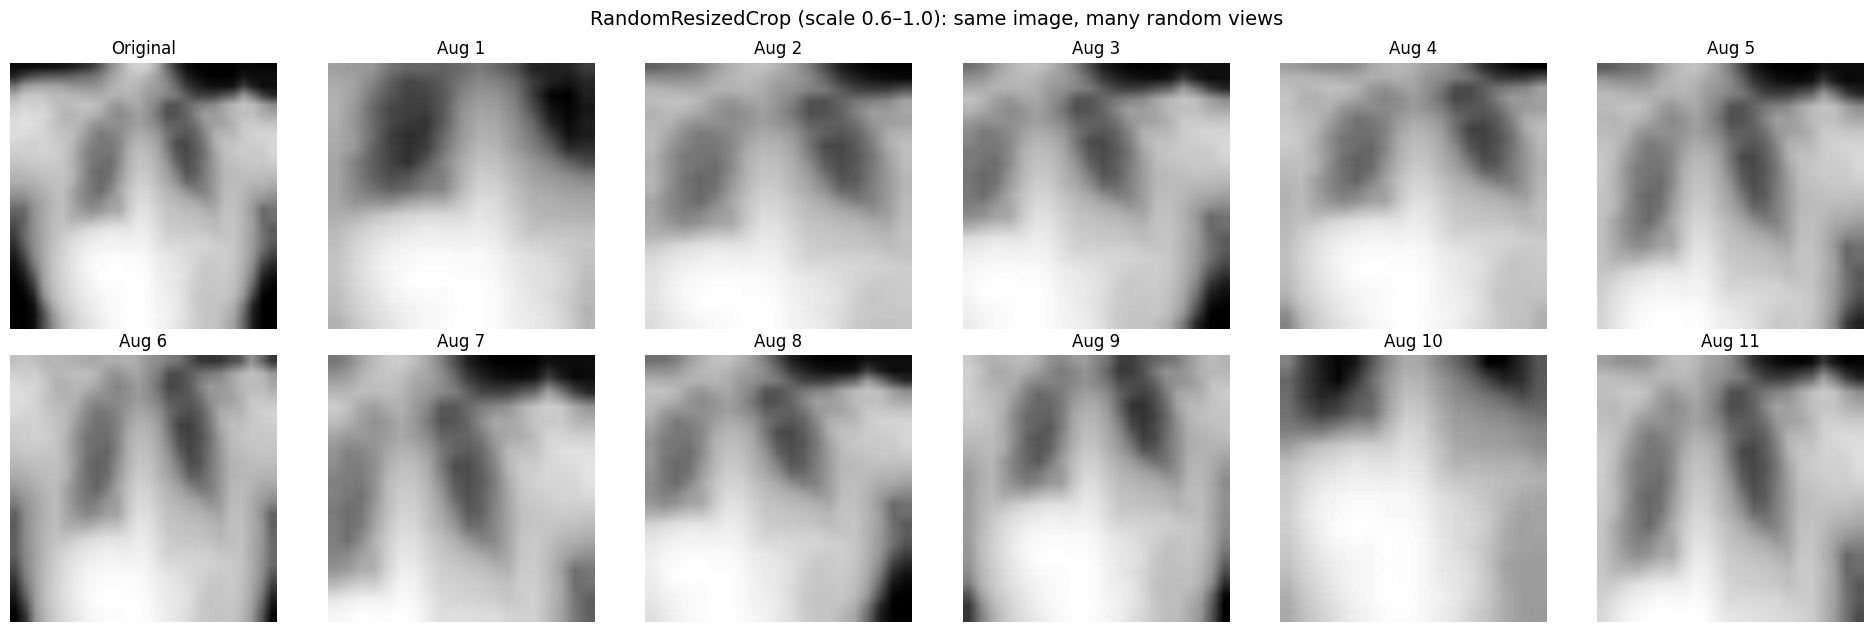

In [16]:
crop_aug = transforms.Compose([
    transforms.RandomResizedCrop(
        size=(224, 224),
        scale=(0.3, 1.0),     # zoom range (smaller -> more zoom-in)
        ratio=(0.7, 1.3)      # keep aspect close to 1
    ),
    transforms.ToTensor(),
])

train_ds_crop = ChestMNIST(
    split="train",
    root=DATA_ROOT,
    download=False,
    transform=crop_aug
)

show_augmentations(
    ds_no_aug=train_ds_no_aug_vis,
    ds_aug=train_ds_crop,
    index=rand_i,
    n_aug=11,
    title="RandomResizedCrop (scale 0.6–1.0): same image, many random views"
)


### 8.7 Padding + random crop (translation invariance)

Sometimes we want to simulate small translations:

- the patient is slightly shifted
- the anatomy is not perfectly aligned in the frame

A simple way is to:

- pad the image with zeros (or reflection padding)
- then randomly crop back to the original size

This teaches the model that small shifts should not change the diagnosis.


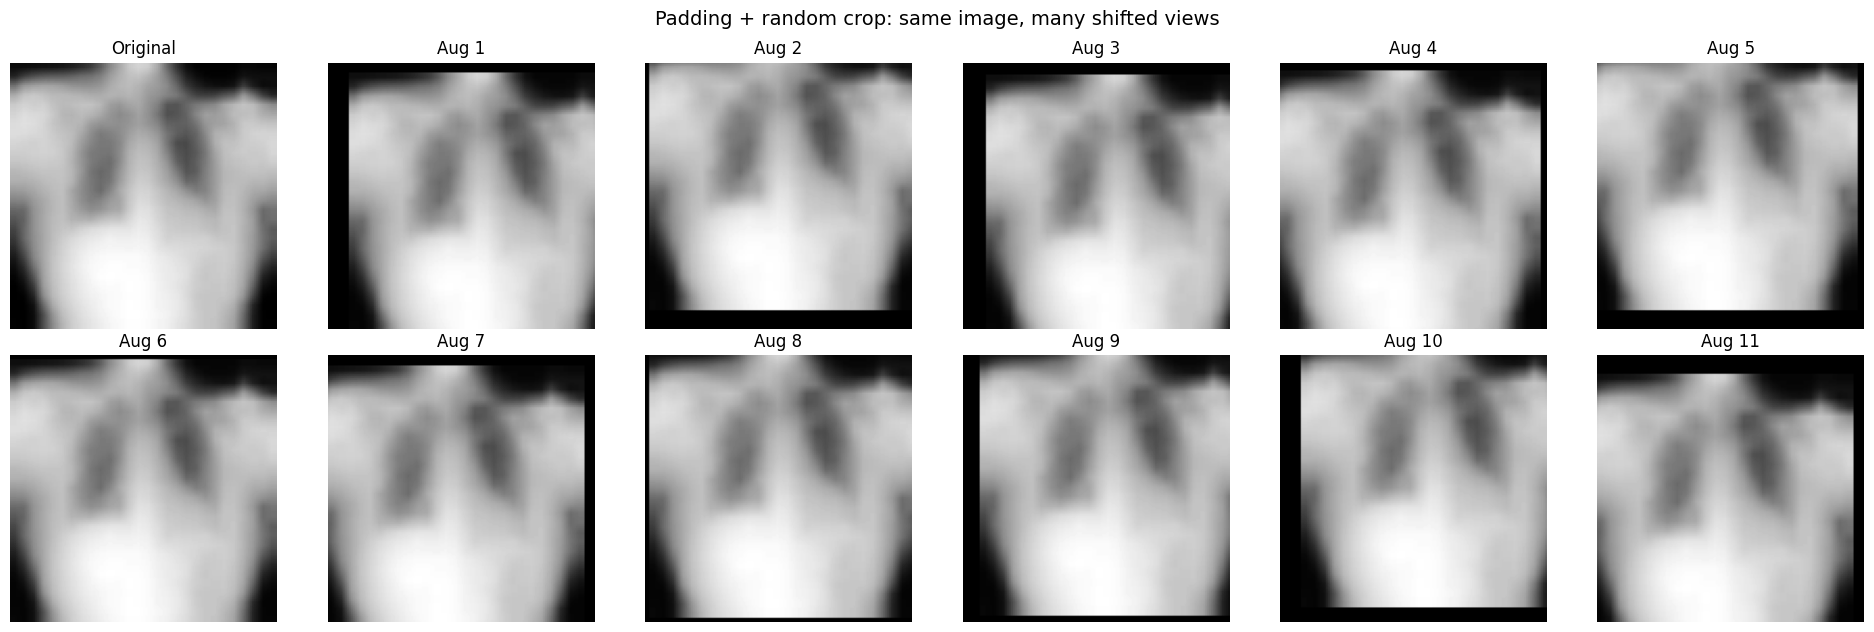

In [17]:
pad_crop_aug = transforms.Compose([
    transforms.Resize((128, 128)),

    # Add padding around the image
    transforms.Pad(padding=12, fill=0),     # adds border

    # Randomly crop back to original size
    transforms.RandomCrop((128, 128)),

    transforms.ToTensor(),
])

train_ds_padcrop = ChestMNIST(
    split="train",
    root=DATA_ROOT,
    download=False,
    transform=pad_crop_aug
)

show_augmentations(
    ds_no_aug=train_ds_no_aug_vis,
    ds_aug=train_ds_padcrop,
    index=rand_i,
    n_aug=11,
    title="Padding + random crop: same image, many shifted views"
)


### 8.8 Elastic deformation (anatomical variability)

Elastic deformation is widely used in segmentation tasks to simulate anatomical variability:

- organ shape differences  
- soft tissue deformation  
- patient-specific structural variation  

This is especially common in MRI/CT segmentation.

**Caution:** It is generally not recommended for chest X-rays,
where global deformations may become anatomically implausible.


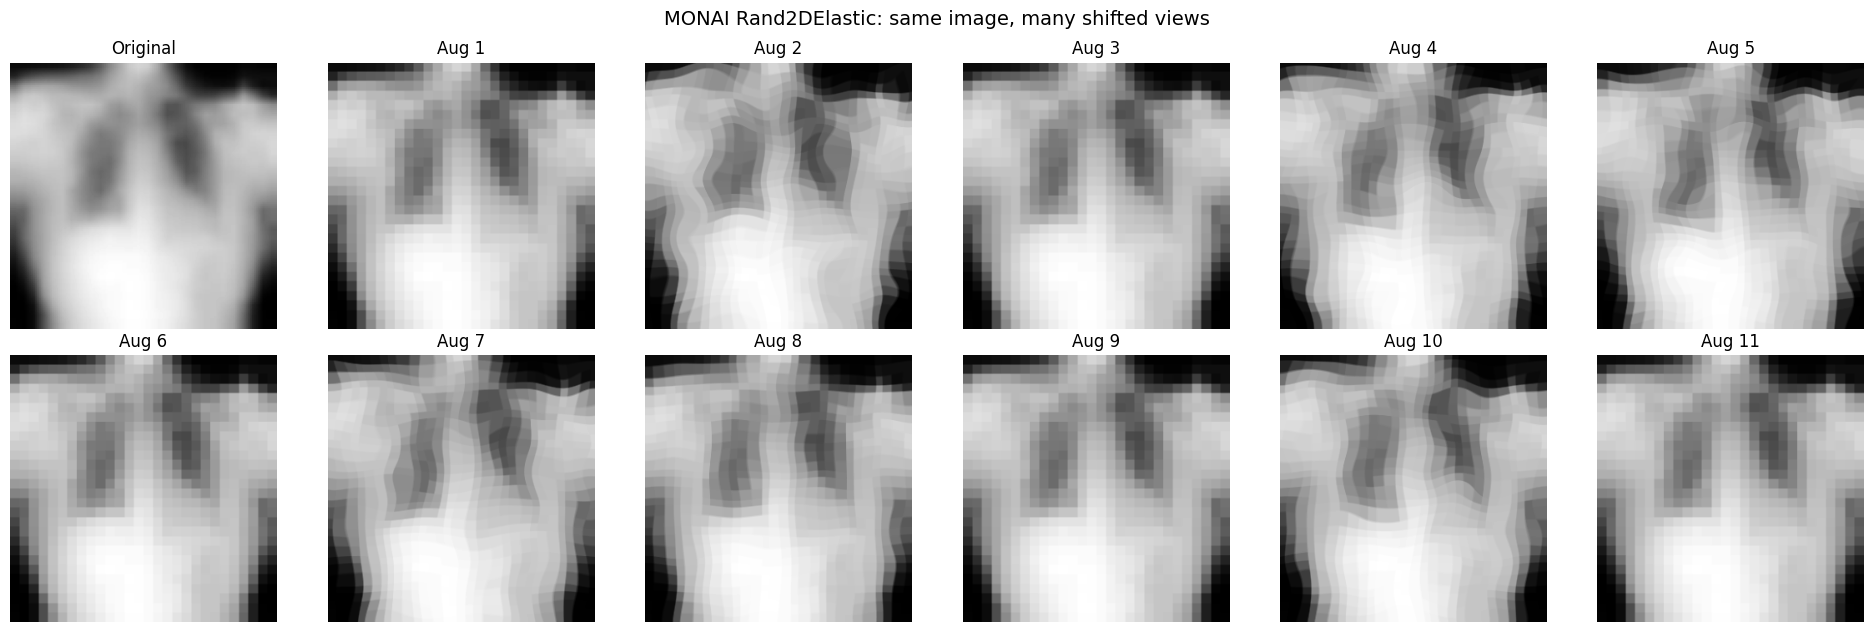

In [18]:
from monai.transforms import Compose, EnsureChannelFirst, Rand2DElastic, Resize, ToTensor
import numpy as np

elastic_aug = Compose([
    lambda img: np.array(img.convert("L"), dtype=np.float32) / 255.0,
    EnsureChannelFirst(channel_dim="no_channel"),

    # first upscale for better visualization
    Resize((320, 320)),

    Rand2DElastic(
        prob=0.3,
        spacing=(35, 35),          # larger spacing for larger image
        magnitude_range=(2.0, 5.0),
        padding_mode="border",
    ),

    # (optional) keep as 224 for visualization
    ToTensor(),
])

train_ds_elastic = ChestMNIST(split="train", root=DATA_ROOT, download=False, transform=elastic_aug)

show_augmentations(
    ds_no_aug=train_ds_no_aug_vis,
    ds_aug=train_ds_elastic,
    index=rand_i,
    n_aug=11,
    title="MONAI Rand2DElastic: same image, many shifted views"
)


### 8.9 Histogram-based augmentation (scanner harmonization)

A major challenge in medical AI is **domain shift**:

- Scanner A vs Scanner B  
- Institution-to-institution differences  
- Different reconstruction pipelines  

Histogram-based augmentations simulate intensity distribution shifts,
helping models generalize across sites.

This is one of the most clinically relevant augmentations for multi-center studies.


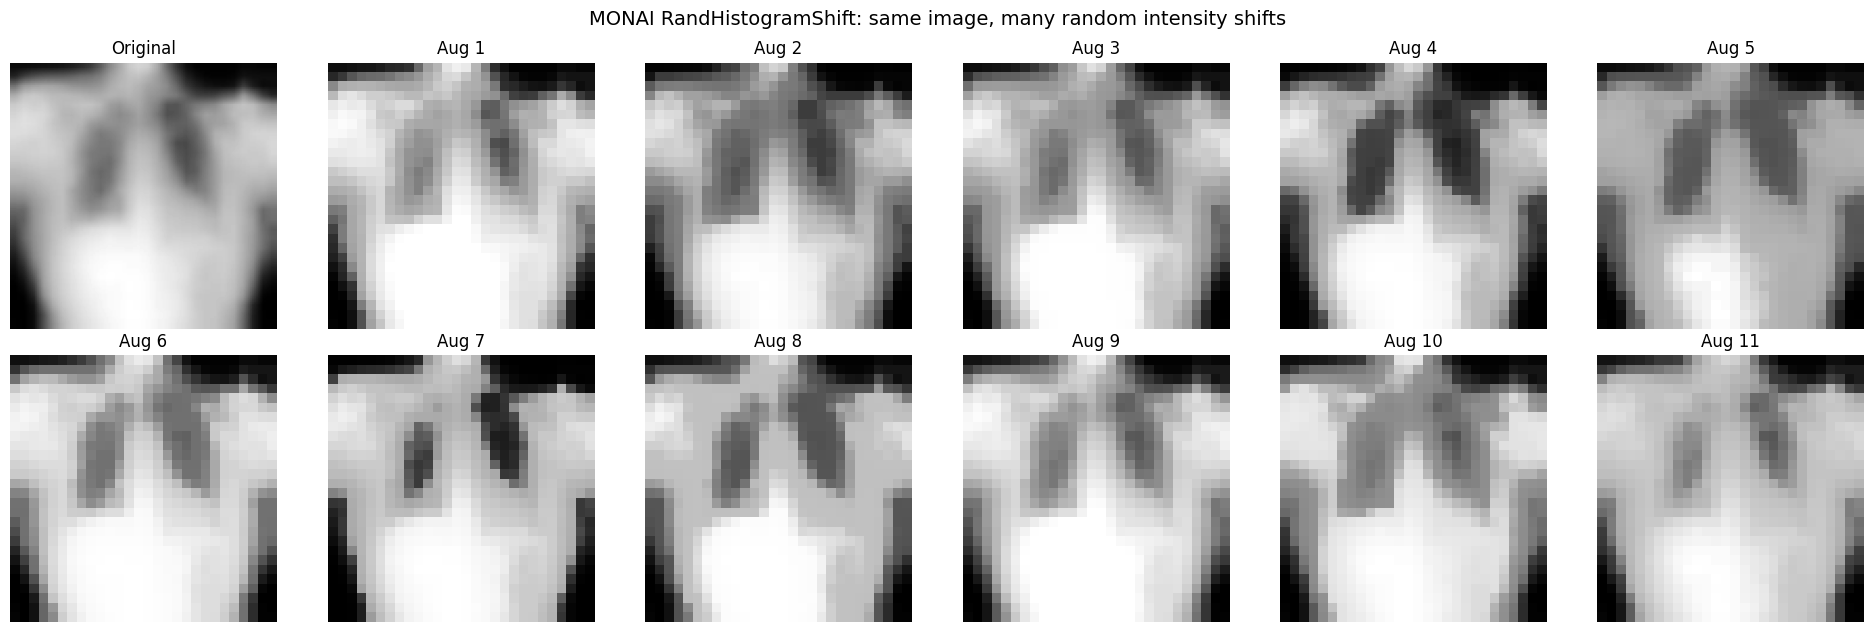

In [19]:
import numpy as np
from monai.transforms import Compose, EnsureChannelFirst, RandHistogramShift, ToTensor

hist_aug = Compose([
    # PIL -> numpy float32 [0,1]
    lambda img: np.array(img.convert("L"), dtype=np.float32) / 255.0,

    # add channel dim safely
    EnsureChannelFirst(channel_dim="no_channel"),

    RandHistogramShift(
        prob=1.0,               # set 1.0 for visualization
        num_control_points=10
    ),

    ToTensor(),
])

train_ds_hist = ChestMNIST(
    split="train",
    root=DATA_ROOT,
    download=False,
    transform=hist_aug
)

show_augmentations(
    ds_no_aug=train_ds_no_aug_vis,
    ds_aug=train_ds_hist,
    index=rand_i,
    n_aug=11,
    title="MONAI RandHistogramShift: same image, many random intensity shifts"
)


## 9. Mixed augmentation pipeline

In training, multiple augmentations are typically combined.  
Below we mix rotation + intensity jitter + noise and visualize many stochastic views.


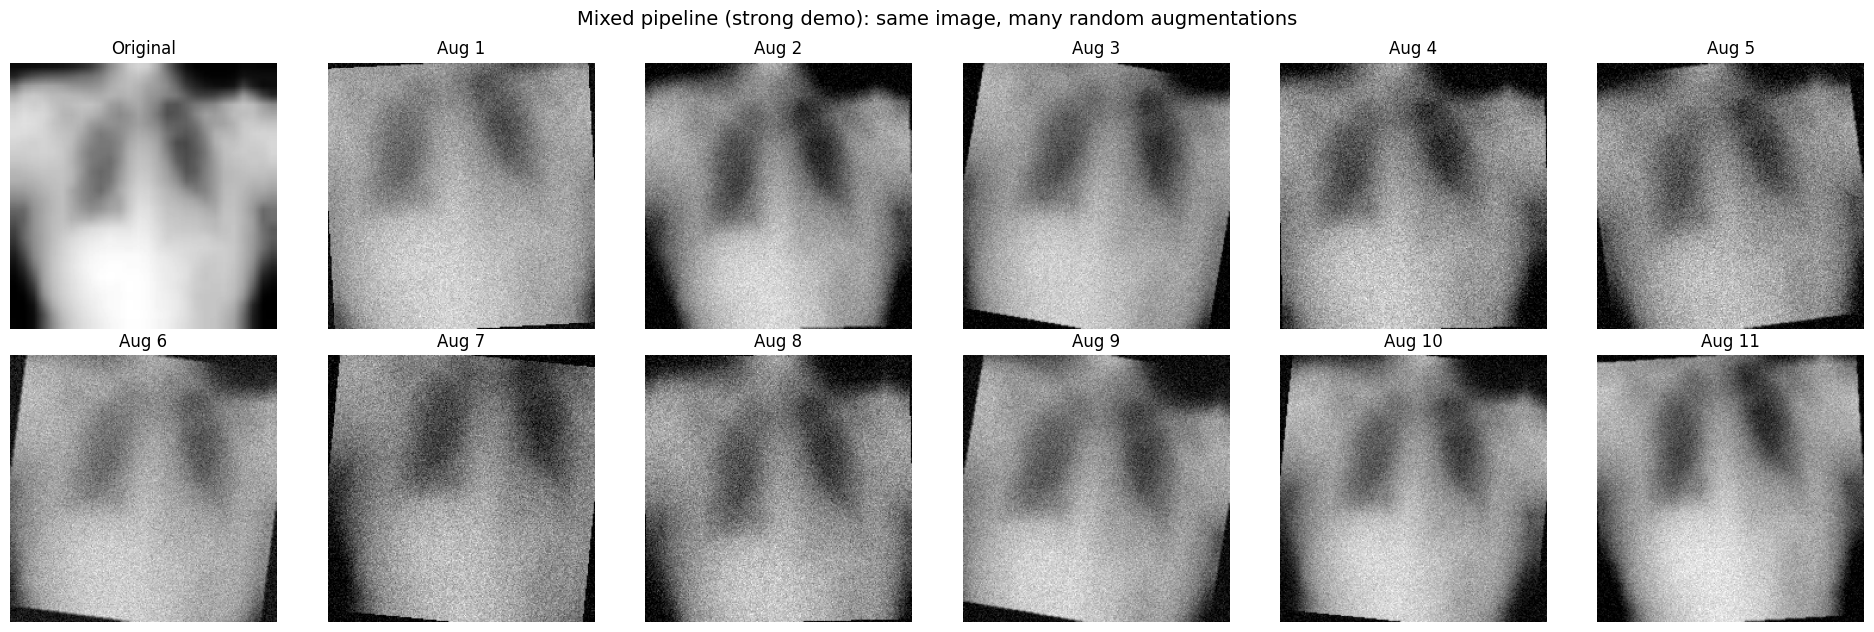

In [20]:
train_aug_demo = transforms.Compose([
    # 1) Zoom + framing variability
    transforms.RandomResizedCrop(
        size=(224, 224),
        scale=(0.75, 1.0),
        ratio=(0.9, 1.1)
    ),

    # 2) Mild rotation (keep plausible)
    transforms.RandomRotation(degrees=15),

    # 3) Windowing-like intensity variability
    transforms.ColorJitter(brightness=0.25, contrast=0.25),

    # 4) Occasional blur (motion)
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),

    transforms.ToTensor(),

    # 5) Gamma correction (scanner harmonization)
    transforms.Lambda(
        lambda x: torch.clamp(x ** float(np.random.uniform(0.8, 1.3)), 0, 1)
    ),

    # 6) Gaussian noise (acquisition noise)
    transforms.Lambda(
        lambda x: torch.clamp(
            x + torch.normal(0.0, 0.05, size=x.shape),
            0, 1
        )
    ),
])


train_ds_aug_demo = ChestMNIST(split="train", transform=train_aug_demo, root=DATA_ROOT, download=False)

show_augmentations(
    ds_no_aug=train_ds_no_aug_vis,
    ds_aug=train_ds_aug_demo,
    index=rand_i,
    n_aug=11,
    title="Mixed pipeline (strong demo): same image, many random augmentations"
)


## 10. Validation pipeline: deterministic preprocessing only

Validation should reflect the real distribution and be **stable**.  
A quick consistency check: the “same image” should look identical every time when no stochastic transforms are applied.


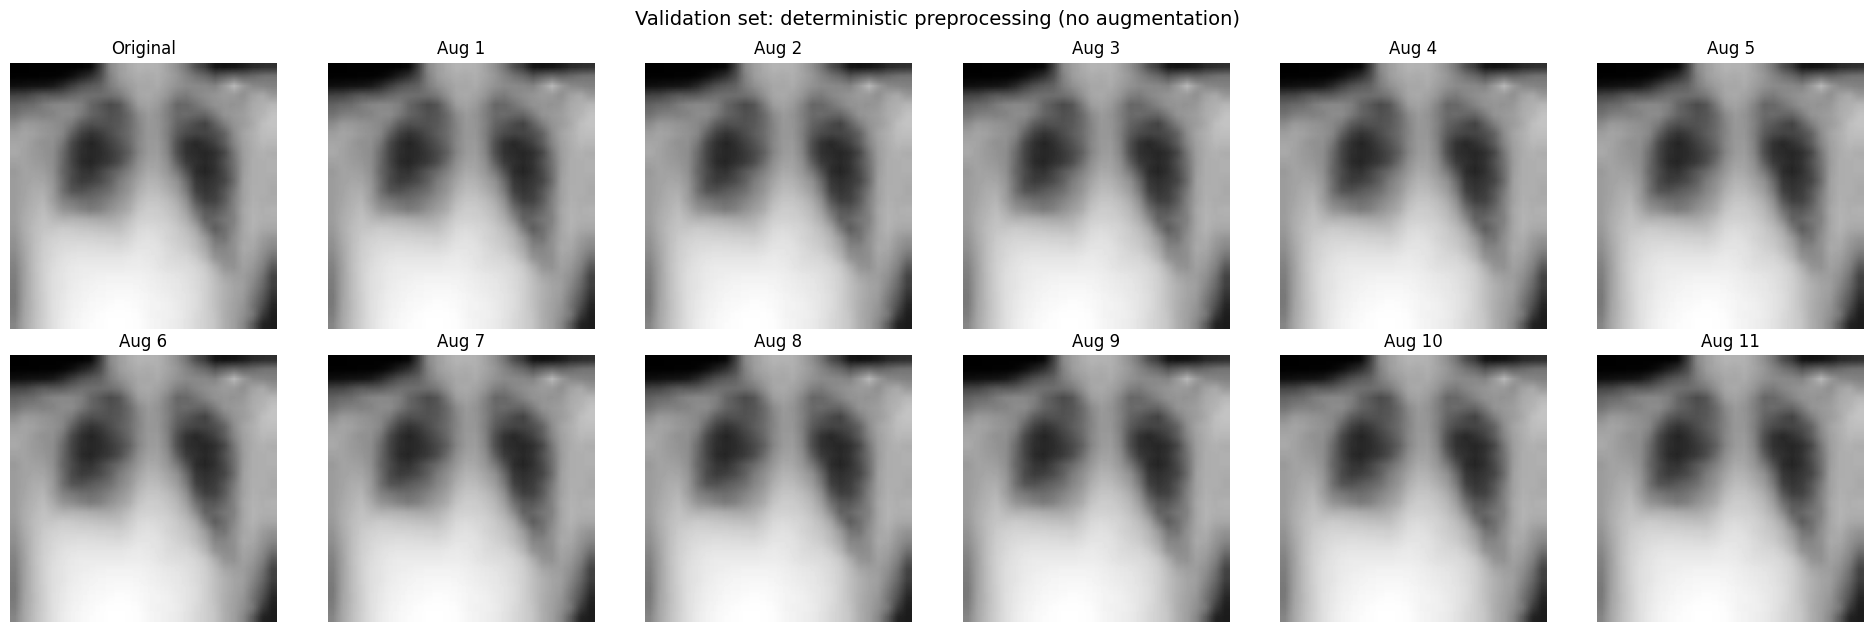

In [21]:
val_ds_vis = ChestMNIST(split="val", transform=preprocess, root=DATA_ROOT, download=False)
val_i = random.randint(0, len(val_ds_vis) - 1)

show_augmentations(
    ds_no_aug=val_ds_vis,
    ds_aug=val_ds_vis,
    index=val_i,
    n_aug=11,
    title="Validation set: deterministic preprocessing (no augmentation)"
)


## 11. Practical guidance: choosing augmentations

A simple process:
1. Start from **real-world variation** in your data (positioning, scanner noise, intensity differences).
2. Keep transforms **clinically plausible**.
3. Visualize before training.
4. If performance drops, reduce augmentation strength or remove the transform.


## 12. Checklist
Use this checklist for your own projects.

#### Data loaders
- [ ] Split at **patient/study level** when possible (avoid leakage)
- [ ] Apply **augmentation only to training**
- [ ] Keep validation/test preprocessing **deterministic**
- [ ] Set seeds when debugging

#### Augmentations
- [ ] Clinically plausible ranges (rotation, noise, contrast)
- [ ] Avoid transforms that break anatomy
- [ ] Inspect grids: original vs many stochastic views


## 13. It's Your Turn

1. Reduce rotation from ±50° to ±10° and compare.
2. Reduce noise σ from 0.1 to 0.03–0.05 and compare.
3. Remove flips and see whether laterality-sensitive tasks change.
4. Build two pipelines (mild vs strong) and compare validation stability.
